In [73]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm import tqdm
import pickle

from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split

from utils.vizualizations import plot_bias_using_QQ_plot

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [ ]:
PICKLE_FILE_PATH_A = "./data/filtered_chirps_reprojected.pkl"
PICKLE_FILE_PATH_B = "./data/filtered_chirps.pkl"

with open(PICKLE_FILE_PATH_A, "rb") as f:
    chirps_reprojected = pickle.load(f)

with open(PICKLE_FILE_PATH_B, "rb") as f:
    chirps = pickle.load(f)

In [75]:
trainA = np.array(list(chirps_reprojected.values()))
trainB = np.array(list(chirps.values()))

In [76]:
x_train, x_test, y_train, y_test = train_test_split(trainA, trainB, test_size=0.2, shuffle=False, random_state=88)

In [77]:
def create_small_images(small_image_size, big_images):
    small_images = {}
    for x in big_images:
        x = x.reshape(-1, small_image_size, small_image_size) # (1024, 16, 16)
        for i, img in enumerate(x):
            if i in small_images:
                small_images[i].append(img.flatten())
            else:
                small_images[i] = [img.flatten()]
    return small_images

In [78]:
def reconstruct_images(small_image_size, predicted_small_images):
    pred_images = []
    for i in range(predicted_small_images.shape[1]):
        pred_images.append(predicted_small_images[:,i,:].reshape(-1, small_image_size, small_image_size).reshape(64, 64))
    return np.array(pred_images)

In [79]:
def postprocess_image(image):
    # Model bias correction 1
    # Replace negative values with zero (-ve precipitation has no meaning)
    image[image < 0.0] = 0.0
    return image

In [80]:
SMALL_IMAGE_SIZE = 8
x_train_small = create_small_images(SMALL_IMAGE_SIZE, x_train)
x_test_small = create_small_images(SMALL_IMAGE_SIZE, x_test)
y_train_small = create_small_images(SMALL_IMAGE_SIZE, y_train)
y_test_small = create_small_images(SMALL_IMAGE_SIZE, y_test)

In [81]:
models = []
D = len(x_train)
train_dataset = list(zip(x_train_small.values(), y_train_small.values()))
# train_dataset = list(zip(x_train, y_train))
for x, y in tqdm(train_dataset, desc="Training Models", colour="BLUE"):
    model = LinearRegression(n_jobs=-1)
    # model = RandomForestRegressor(n_estimators=100, n_jobs=-1)
    # model = DecisionTreeRegressor()
    model.fit(x, y)
    models.append(model)

Training Models: 100%|██████████| 64/64 [00:00<00:00, 967.93it/s]


In [82]:
predictions = []
model_and_test_data = list(zip(models, x_test_small.values()))
for model, x in tqdm(model_and_test_data, desc = "Getting Predictions", colour="GREEN"):
    prediction = model.predict(x)
    predictions.append(prediction)
predictions = np.array(predictions)
predictions.shape

Getting Predictions: 100%|██████████| 64/64 [00:00<00:00, 5252.63it/s]


(64, 137, 64)

In [83]:
pred_images = reconstruct_images(SMALL_IMAGE_SIZE, predictions)
for i in range(len(pred_images)):
    pred_images[i] = postprocess_image(pred_images[i])
# pred_images = predictions

In [84]:
flattened_test = np.array(y_test).reshape(-1, 64*64)
flattened_pred = pred_images.reshape(-1, 64*64)
mse = mean_squared_error(flattened_test, flattened_pred)
r2 = r2_score(flattened_test, flattened_pred)
print(f"Mean Squred Error = {mse:0.3f}\nR^2 Score = {r2:0.3f}")

Mean Squred Error = 119.609
R^2 Score = 0.705


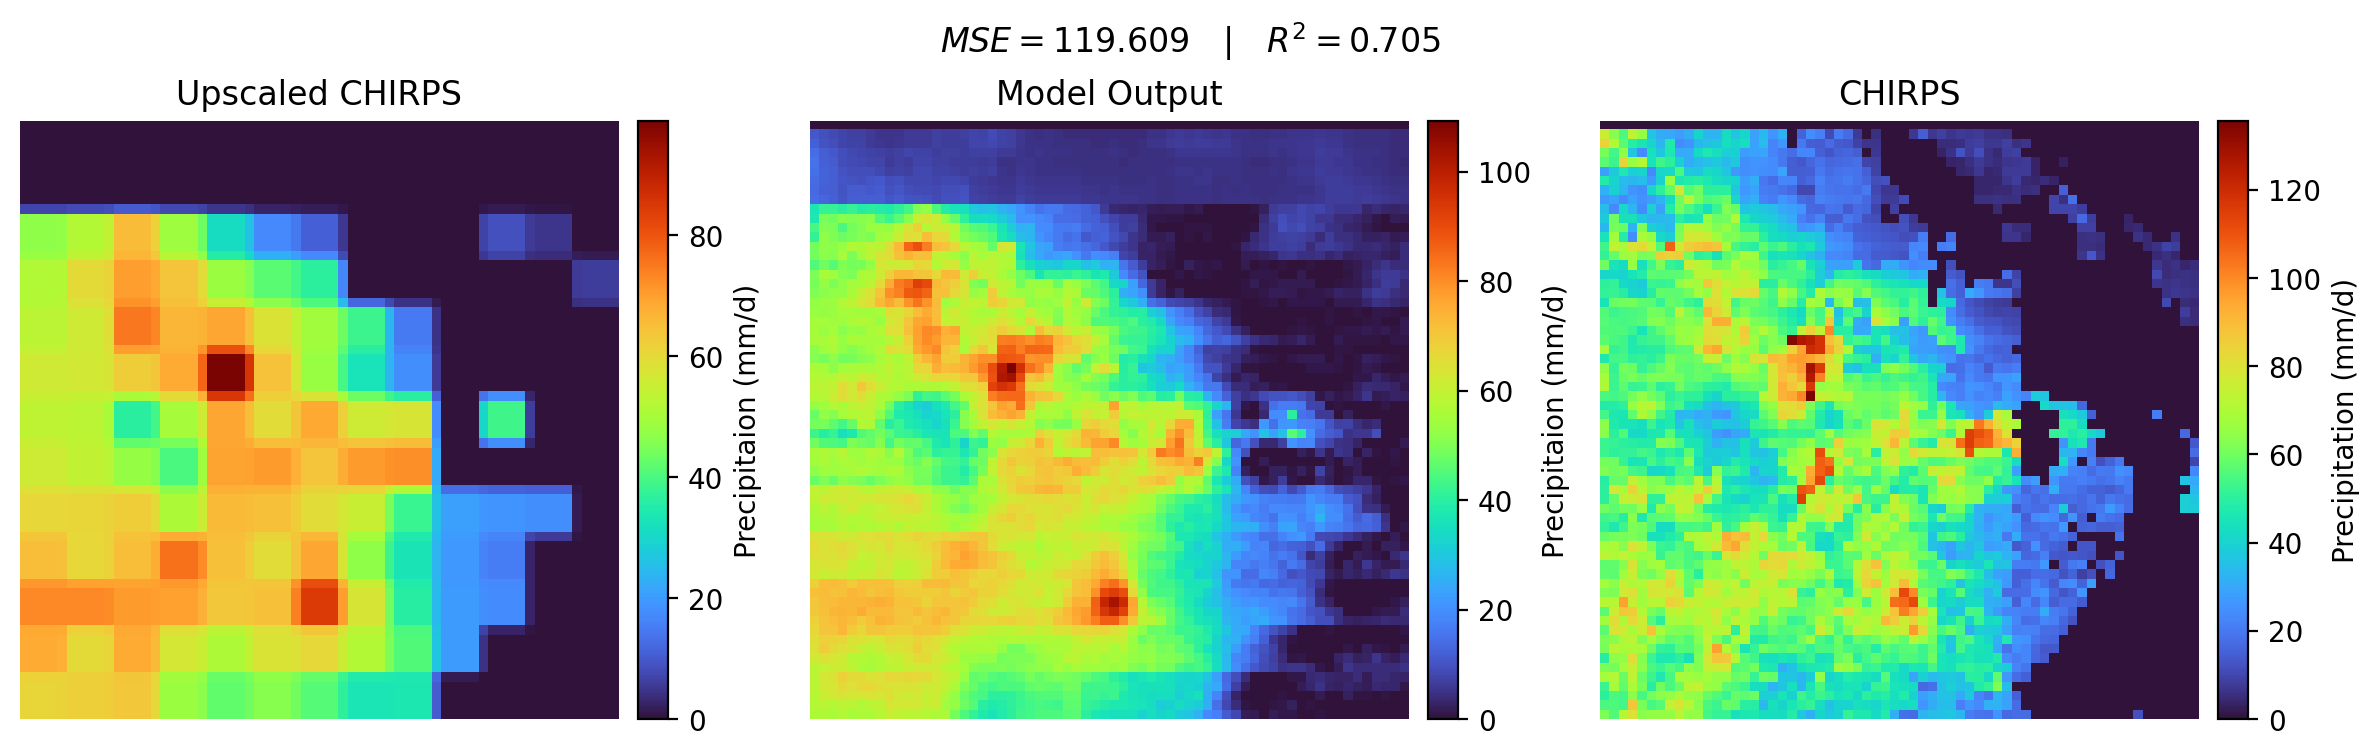

In [85]:
i = 0
fig,axs = plt.subplots(1, 3, figsize=(12,7), dpi=200)

image_0 = axs[0].imshow(x_test[i], cmap="turbo")
axs[0].set_title("Upscaled CHIRPS")
axs[0].set_axis_off()
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=.1)
plt.colorbar(image_0, cax=cax, label="Precipitaion (mm/d)")

image_1 = axs[1].imshow(pred_images[i], cmap="turbo")
axs[1].set_title("Model Output")
axs[1].set_axis_off()
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=.1)
plt.colorbar(image_1, cax=cax, label="Precipitaion (mm/d)")

image_2 = axs[2].imshow(y_test[i], cmap="turbo")
axs[2].set_title("CHIRPS")
axs[2].set_axis_off()
divider = make_axes_locatable(axs[2])
cax = divider.append_axes("right",size="5%", pad=0.1)
plt.colorbar(image_2, cax=cax, label="Precipitation (mm/d)")

plt.suptitle("$MSE = %0.3f \\quad|\\quad R^2 = %0.3f$" %(mse, r2), x=0.5, y=0.76)
plt.tight_layout()

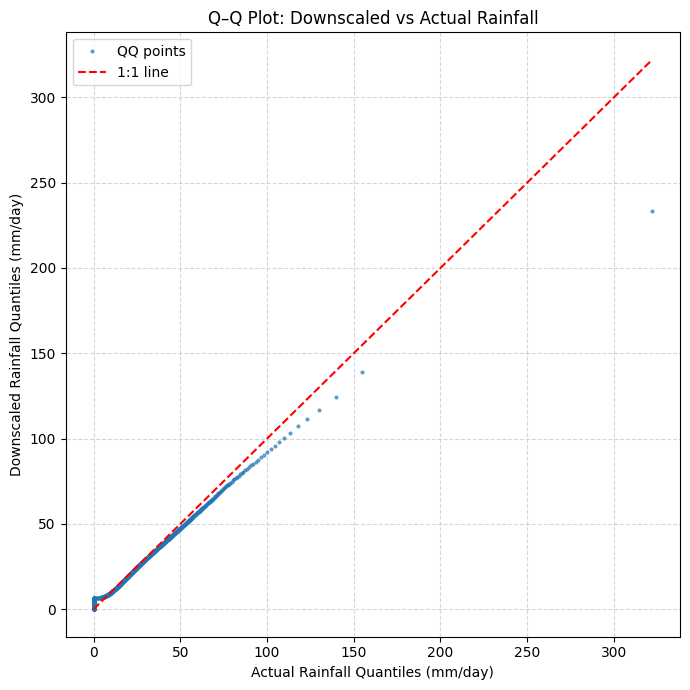

Mean Bias: -0.032
RMSE: 10.937


In [86]:
plot_bias_using_QQ_plot(pred_images, y_test)

In [ ]:
small_images = pred_images[:,0,:].swapaxes(0,1).reshape(-1, SMALL_IMAGE_SIZE, SMALL_IMAGE_SIZE)
rows = small_images.shape[0]//2
cols = rows
fig, axs = plt.subplots(rows, cols, figsize=(12, 12), dpi=500)
for r in range(rows):
    for c in range(cols):
        idx = r+c
        axs[r, c].imshow(postprocess_image(small_images[idx]), cmap="turbo")
        axs[r, c].set_axis_off()
plt.subplots_adjust(
    wspace=0.1, # width space between subplots
    hspace=0.1  # height space between subplots
)
plt.suptitle("All small images which make up prediction")